import pandas as pd

In [2]:
df=pd.read_csv("retail_sales_data.csv")

In [3]:
df.head()

,transaction_id,date,category,product,price,quantity,total
0,10001,2025-08-01,Clothing,Socks,41.86,3.0,125.58
1,10002,2025-08-01,Groceries,Eggs,NaN,1.0,11.52
2,10003,2025-08-01,Electronics,Webcam,67.75,NaN,135.50
3,10004,2025-08-01,Groceries,Milk,4.03,3.0,NaN
4,10005,2025-08-01,Clothing,NaN,28.37,1.0,28.37


In [10]:
df.shape

(100, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  100 non-null    int64  
 1   date            94 non-null     object 
 2   category        95 non-null     object 
 3   product         97 non-null     object 
 4   price           94 non-null     float64
 5   quantity        91 non-null     float64
 6   total           93 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 5.6+ KB


In [6]:
df.describe()

,transaction_id,price,quantity,total
count,100.000000,94.000000,91.000000,93.000000
mean,10050.500000,27.669255,2.516484,66.095699
std,29.011492,22.039129,1.158185,59.567726
min,10001.000000,2.330000,1.000000,2.330000
25%,10025.750000,13.005000,1.000000,24.550000
50%,10050.500000,21.680000,3.000000,49.470000
75%,10075.250000,34.655000,4.000000,88.760000
max,10100.000000,96.890000,4.000000,358.880000


In [11]:
df.columns

Index(['transaction_id', 'date', 'category', 'product', 'price', 'quantity',
       'total'],
      dtype='object')

In [12]:
df.isnull()

,transaction_id,date,category,product,price,quantity,total
0,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,False,True
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False
97,False,True,False,False,False,False,False
98,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

transaction_id    0
date              6
category          5
product           3
price             6
quantity          9
total             7
dtype: int64

In [25]:
# fill missing quantity or price with 0 (or median if perferred)
df['quantity']=df['quantity'].fillna(0)
df['price']=df['price'].fillna(0)
df['revenue']=df['quantity']*df['price']

In [27]:
print(df[['quantity','price']].head())

   quantity  price
0       3.0  41.86
1       1.0   0.00
2       0.0  67.75
3       3.0   4.03
4       1.0  28.37


In [29]:
category_revenue=df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print(category_revenue)

category
Electronics    2219.94
Clothing       1276.42
Books           988.48
Home Goods      594.31
Groceries       363.15
Name: revenue, dtype: float64


In [31]:
import matplotlib.pyplot as plt

<Axes: xlabel='category'>

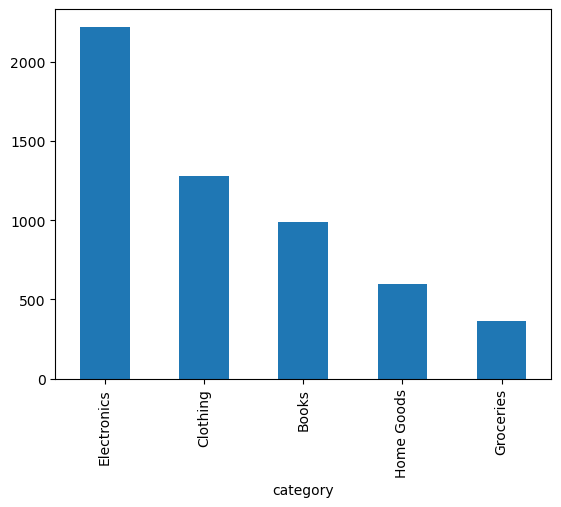

In [33]:
category_revenue.plot(kind='bar')

Text(0.5, 1.0, 'Revenue by category')

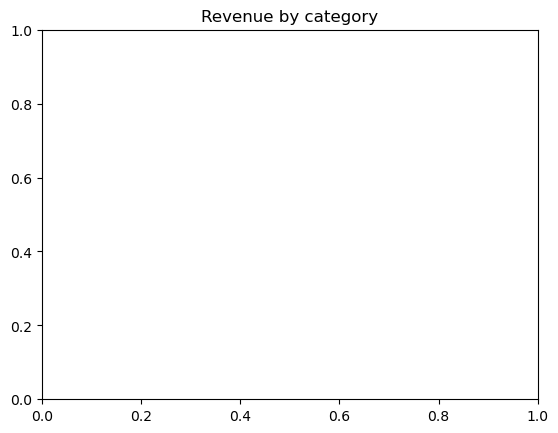

In [34]:
plt.title("Revenue by category")

Text(0.5, 0, 'category')

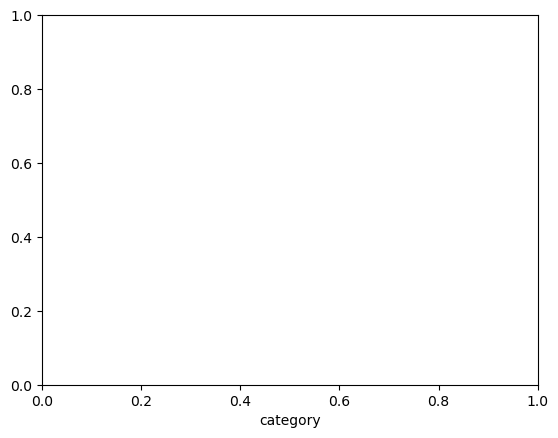

In [35]:
plt.xlabel("category")

Text(0, 0.5, 'Revenue')

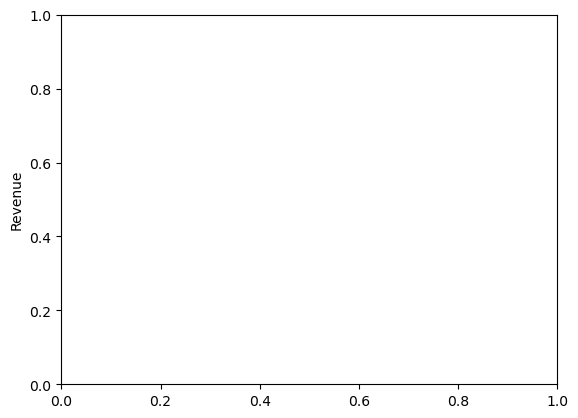

In [36]:
plt.ylabel("Revenue")

In [13]:
import matplotlib.pyplot as plt
plt.show()

In [10]:
import pandas as pd
df=pd.read_csv("retail_sales_data.csv")
top_qty=df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)
top_revenue=df.groupby("product")["total"].sum().sort_values(ascending=False).head(5)

In [11]:
print(top_qty)

product
Self-Help          22.0
Children's Book    17.0
Jacket             16.0
Hat                13.0
Coffee             12.0
Name: quantity, dtype: float64


In [12]:
print(top_revenue)

product
Power Bank         844.03
Smartphone         504.54
Headphones         450.34
Jacket             417.05
Children's Book    340.52
Name: total, dtype: float64


In [20]:
product_summary=df.groupby("product").agg({
    "quantity":'sum',
    "total":'sum'
}).sort_values(by="quantity", ascending=False)
print(product_summary.head(10))

                 quantity   total
product                          
Self-Help            22.0  337.99
Children's Book      17.0  340.52
Jacket               16.0  417.05
Hat                  13.0  319.21
Coffee               12.0  115.22
Power Bank           12.0  844.03
Plate Set            12.0  327.24
T-Shirt              11.0  303.06
Fiction Novel        11.0  247.53
Cereal               10.0  109.31


In [26]:
df["date"]=pd.to_datetime(df["date"])
df["day"]=df["date"].dt.day_name()

In [27]:
df["day"]

0        Friday
1        Friday
2        Friday
3        Friday
4        Friday
        ...    
95      Tuesday
96      Tuesday
97          NaN
98      Tuesday
99    Wednesday
Name: day, Length: 100, dtype: object

In [29]:
sales_by_day=df.groupby("day")["total"].sum().round(2)

In [32]:
print(sales_by_day)
most_sales_day=sales_by_day.idxmax()
most_sales=sales_by_day.max()
print(f"Days with the most sales are '{most_sales_day}'s' with total sales of '${most_sales}'")

day
Friday        812.82
Monday       1008.80
Saturday     1724.53
Sunday       1692.76
Tuesday       645.61
Wednesday      62.48
Name: total, dtype: float64
Days with the most sales are 'Saturday's' with total sales of '$1724.53'


NameError: name 'plt' is not defined

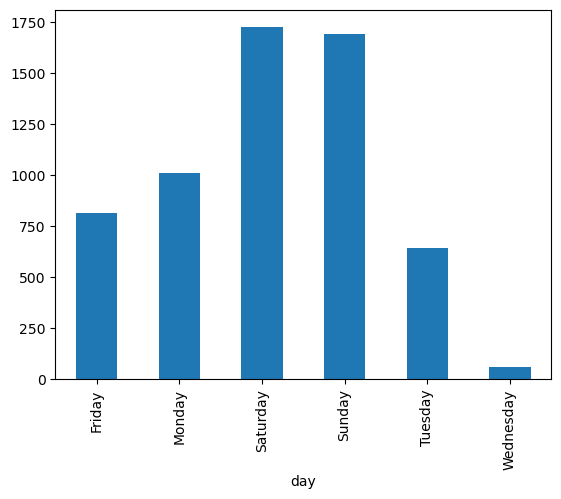

In [34]:
sales_by_day.plot(kind='bar')
plt.title("Sales by Week Days")
plt.xlabel("Days")
plt.xyabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

In [36]:
df.describe()

,transaction_id,date,price,quantity,total,hour
count,100.000000,94,94.000000,91.000000,93.000000,94.0
mean,10050.500000,2025-08-02 22:43:24.255319040,27.669255,2.516484,66.095699,0.0
min,10001.000000,2025-08-01 00:00:00,2.330000,1.000000,2.330000,0.0
25%,10025.750000,2025-08-02 00:00:00,13.005000,1.000000,24.550000,0.0
50%,10050.500000,2025-08-03 00:00:00,21.680000,3.000000,49.470000,0.0
75%,10075.250000,2025-08-04 00:00:00,34.655000,4.000000,88.760000,0.0
max,10100.000000,2025-08-06 00:00:00,96.890000,4.000000,358.880000,0.0
std,29.011492,NaN,22.039129,1.158185,59.567726,0.0


In [5]:
import pandas as pd
df=pd.read_csv("retail_sales_data.csv")
avg_transaction_value=df["total"].mean()
print(f'average transaction value=${avg_transaction_value:.2f}')

average transaction value=$66.10


In [6]:
import pandas as pd
df=pd.read_csv("retail_sales_data.csv")
avg_quantity=df['quantity'].mean()
print(f'Average Quantity={avg_quantity:.0f}')

Average Quantity=3


In [7]:
price_range=df.groupby('category')['price'].agg(["min","max"])
print(price_range.round(2))

               min    max
category                 
Books        10.01  29.48
Clothing     10.92  44.52
Electronics  35.68  96.89
Groceries     2.33  14.55
Home Goods    5.49  38.95
